# Mutual Fund Analytics – Performance Analytics

## Objective

This notebook evaluates the financial performance of mutual fund schemes using key performance metrics.

Metrics covered:

- CAGR
- Annualized Return
- Volatility
- Sharpe Ratio
- Beta
- Alpha
- Maximum Drawdown
- Value at Risk (VaR)

Author: Sathvika G Naik

In [2]:
import sqlite3
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)

In [3]:
DATABASE = "../data/db/bluestock_mf.db"

conn = sqlite3.connect(DATABASE)

scheme = pd.read_sql(
    "SELECT * FROM scheme_performance",
    conn
)

nav = pd.read_sql(
    "SELECT * FROM nav_history",
    conn
)

conn.close()

print("Loaded Successfully")

Loaded Successfully


In [4]:
scheme.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
cagr = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values("date")

    beginning = df.iloc[0]["nav"]
    ending = df.iloc[-1]["nav"]

    years = (
        df["date"].max() -
        df["date"].min()
    ).days / 365.25

    value = (
        (ending / beginning) ** (1 / years) - 1
    ) * 100

    cagr.append([code, round(value,2)])

cagr = pd.DataFrame(
    cagr,
    columns=[
        "amfi_code",
        "CAGR (%)"
    ]
)

cagr.head()

,amfi_code,CAGR (%)
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [6]:
performance = pd.merge(
    scheme,
    cagr,
    on="amfi_code"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR (%)
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,25.80
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,21.52
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,32.42
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,2.05
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,5.89


In [7]:
top = (
    performance
    .sort_values(
        "CAGR (%)",
        ascending=False
    )
    .head(10)
)

top

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR (%)
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High,32.83
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,32.42
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High,32.29
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,0.98,0.80,1.03,17.0,-22.62,2989,1.60,5,High,31.95
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,30.97
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High,30.91
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High,30.12
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High,29.58
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High,28.21
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,25.80


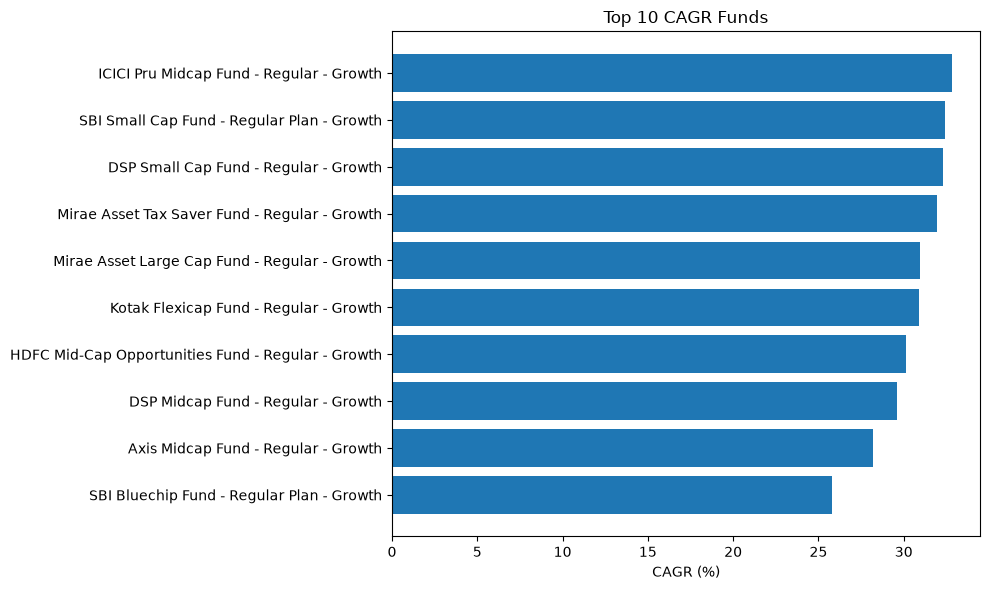

In [8]:
plt.barh(
    top["scheme_name"],
    top["CAGR (%)"]
)

plt.title("Top 10 CAGR Funds")

plt.xlabel("CAGR (%)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Insight

The CAGR metric shows the average annual growth rate of each mutual fund over the available NAV history. Funds with higher CAGR have demonstrated stronger long-term compounded growth, making them attractive for long-term investors. However, CAGR should always be interpreted alongside risk measures such as volatility and Sharpe Ratio.

In [9]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
volatility = (
    nav.groupby("amfi_code")["daily_return"]
       .std()
       * np.sqrt(252)
       * 100
)

volatility = (
    volatility
    .reset_index()
    .rename(columns={
        "daily_return": "Volatility (%)"
    })
)

volatility.head()

,amfi_code,Volatility (%)
0,100016,14.548135
1,100025,3.905246
2,100033,18.936711
3,101206,14.568213
4,101207,25.797322


In [11]:
performance = performance.merge(
    volatility,
    on="amfi_code"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR (%),Volatility (%)
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,25.80,13.741434
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,21.52,13.939368
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,32.42,25.140579
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,2.05,24.950125
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,5.89,3.967062


In [12]:
top_vol = (
    performance
    .sort_values(
        "Volatility (%)",
        ascending=False
    )
    .head(10)
)

top_vol[
    ["scheme_name", "Volatility (%)"]
]

,scheme_name,Volatility (%)
29,ABSL Small Cap Fund - Regular - Growth,25.797322
17,Nippon India Small Cap Fund - Regular - Growth,25.241521
2,SBI Small Cap Fund - Regular Plan - Growth,25.140579
27,Axis Small Cap Fund - Regular - Growth,25.066580
3,SBI Small Cap Fund - Direct Plan - Growth,24.950125
39,DSP Small Cap Fund - Regular - Growth,24.840205
26,Axis Midcap Fund - Regular - Growth,19.407117
12,ICICI Pru Midcap Fund - Regular - Growth,19.290949
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,18.936711
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,18.352430


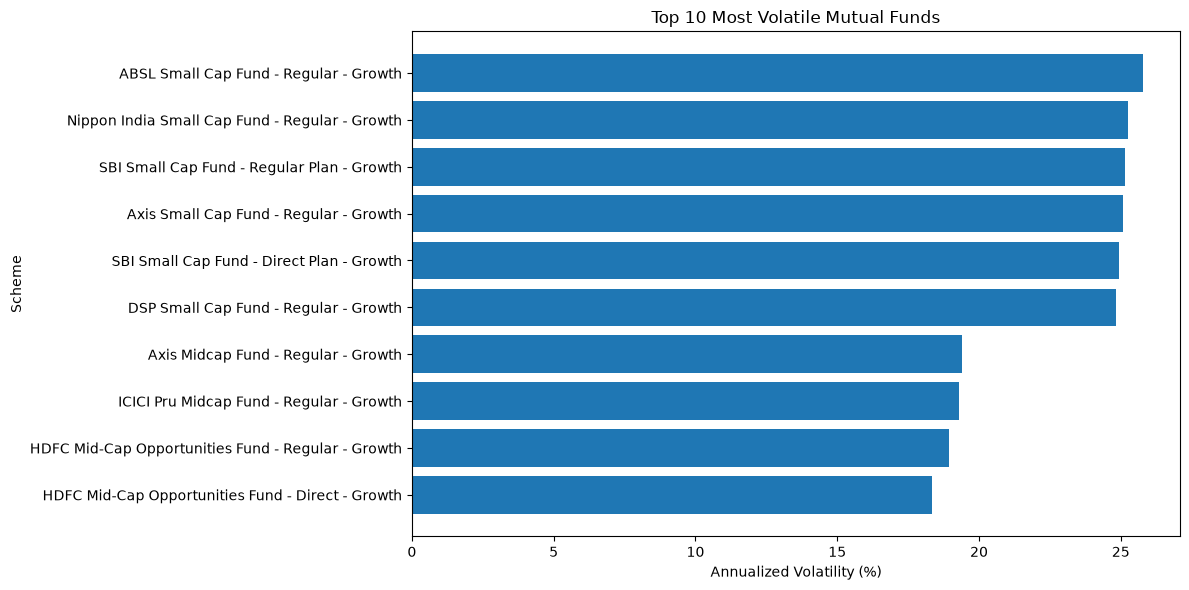

In [13]:
plt.figure(figsize=(12,6))

plt.barh(
    top_vol["scheme_name"],
    top_vol["Volatility (%)"]
)

plt.xlabel("Annualized Volatility (%)")

plt.ylabel("Scheme")

plt.title("Top 10 Most Volatile Mutual Funds")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Insight

Volatility measures the annualized fluctuation in daily NAV returns. Higher volatility indicates greater risk, as fund values experience larger price swings. Investors with lower risk tolerance generally prefer funds with lower volatility.

In [14]:
risk_free_rate = 6  # Annual risk-free rate in %

performance["Sharpe Calculated"] = (
    (performance["CAGR (%)"] - risk_free_rate)
    / performance["Volatility (%)"]
)

performance[
    ["scheme_name", "CAGR (%)", "Volatility (%)", "Sharpe Calculated"]
].head()

,scheme_name,CAGR (%),Volatility (%),Sharpe Calculated
0,SBI Bluechip Fund - Regular Plan - Growth,25.80,13.741434,1.440898
1,SBI Bluechip Fund - Direct Plan - Growth,21.52,13.939368,1.113393
2,SBI Small Cap Fund - Regular Plan - Growth,32.42,25.140579,1.050891
3,SBI Small Cap Fund - Direct Plan - Growth,2.05,24.950125,-0.158316
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.89,3.967062,-0.027728


In [15]:
top_sharpe = (
    performance
    .sort_values(
        "Sharpe Calculated",
        ascending=False
    )
    .head(10)
)

top_sharpe[
    ["scheme_name", "Sharpe Calculated"]
]

,scheme_name,Sharpe Calculated
14,ICICI Pru Liquid Fund - Regular - Growth,2.510566
23,Kotak Liquid Fund - Regular - Growth,1.792265
34,Mirae Asset Large Cap Fund - Regular - Growth,1.759230
22,Kotak Flexicap Fund - Regular - Growth,1.567950
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.468258
0,SBI Bluechip Fund - Regular Plan - Growth,1.440898
12,ICICI Pru Midcap Fund - Regular - Growth,1.390808
38,DSP Midcap Fund - Regular - Growth,1.328738
15,Nippon India Large Cap Fund - Regular - Growth,1.275767
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.273716


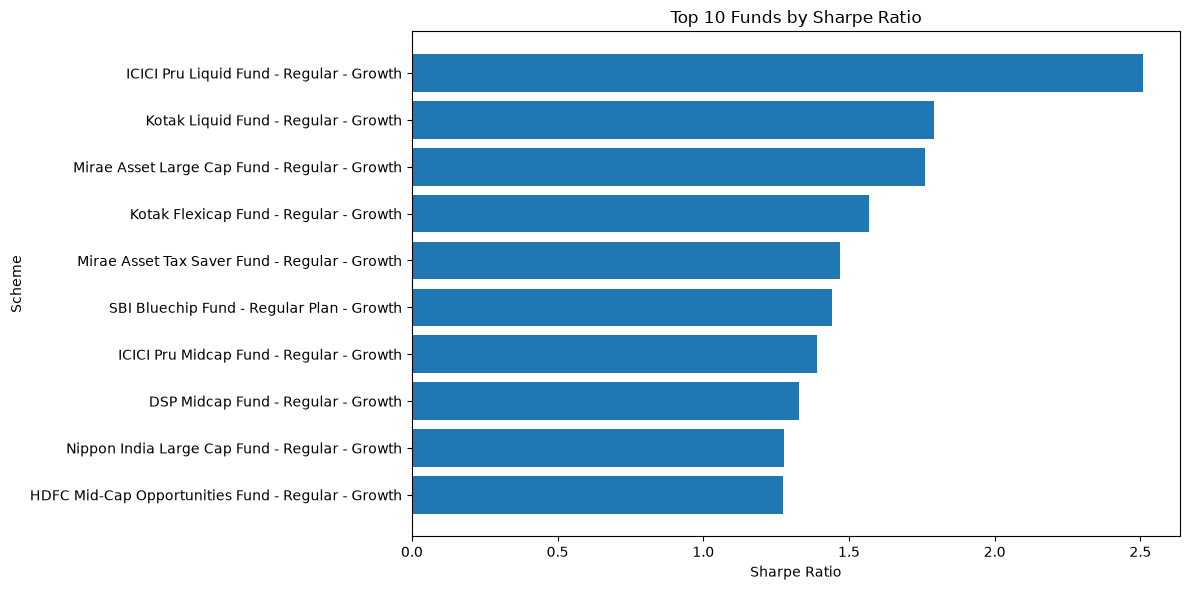

In [16]:
plt.figure(figsize=(12,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["Sharpe Calculated"]
)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Scheme")

plt.title("Top 10 Funds by Sharpe Ratio")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Insight

The Sharpe Ratio evaluates how much return a mutual fund generates for each unit of risk taken. Funds with a higher Sharpe Ratio provide better risk-adjusted returns and are generally considered more efficient investment choices.

In [17]:
drawdown_results = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    df = df.sort_values("date")

    rolling_max = df["nav"].cummax()

    drawdown = (
        (df["nav"] - rolling_max)
        / rolling_max
    )

    max_drawdown = drawdown.min() * 100

    drawdown_results.append(
        [code, round(max_drawdown, 2)]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "Maximum Drawdown (%)"
    ]
)

drawdown_df.head()

,amfi_code,Maximum Drawdown (%)
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [18]:
performance = performance.merge(
    drawdown_df,
    on="amfi_code"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR (%),Volatility (%),Sharpe Calculated,Maximum Drawdown (%)
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14.0,-21.70,14288,1.54,4,Moderate,25.80,13.741434,1.440898,-15.01
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,14.0,-24.43,1231,0.66,3,Moderate,21.52,13.939368,1.113393,-11.80
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,25.0,-13.35,19259,1.43,5,Very High,32.42,25.140579,1.050891,-28.71
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,25.0,-24.78,36061,0.72,4,Very High,2.05,24.950125,-0.158316,-52.57
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,4.0,-2.30,24101,0.77,5,Low,5.89,3.967062,-0.027728,-4.33


In [19]:
worst_drawdown = (
    performance
    .sort_values(
        "Maximum Drawdown (%)"
    )
    .head(10)
)

worst_drawdown[
    ["scheme_name", "Maximum Drawdown (%)"]
]

,scheme_name,Maximum Drawdown (%)
3,SBI Small Cap Fund - Direct Plan - Growth,-52.57
27,Axis Small Cap Fund - Regular - Growth,-51.68
29,ABSL Small Cap Fund - Regular - Growth,-35.45
39,DSP Small Cap Fund - Regular - Growth,-31.17
2,SBI Small Cap Fund - Regular Plan - Growth,-28.71
32,UTI Mid Cap Fund - Regular - Growth,-28.00
5,HDFC Top 100 Fund - Regular Plan - Growth,-24.73
21,Kotak Emerging Equity Fund - Regular - Growth,-24.00
17,Nippon India Small Cap Fund - Regular - Growth,-23.34
25,Axis Bluechip Fund - Direct - Growth,-21.75


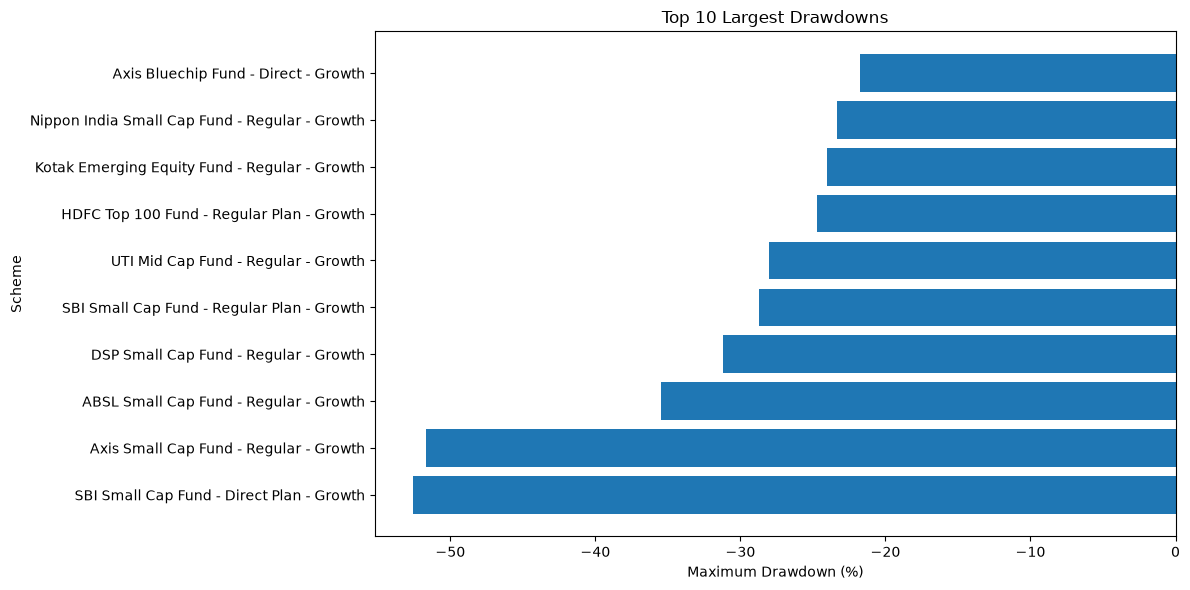

In [20]:
plt.figure(figsize=(12,6))

plt.barh(
    worst_drawdown["scheme_name"],
    worst_drawdown["Maximum Drawdown (%)"]
)

plt.xlabel("Maximum Drawdown (%)")

plt.ylabel("Scheme")

plt.title("Top 10 Largest Drawdowns")

plt.tight_layout()

plt.show()

## Insight

Maximum Drawdown represents the largest percentage decline from a fund's historical peak NAV. Funds with larger drawdowns experienced deeper losses during market downturns, highlighting the importance of considering downside risk in addition to returns.

In [21]:
var_results = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    daily_returns = df["daily_return"].dropna()

    var95 = np.percentile(daily_returns, 5) * 100

    var_results.append(
        [code, round(var95, 2)]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR 95 (%)"
    ]
)

var_df.head()

,amfi_code,VaR 95 (%)
0,100016,-1.44
1,100025,-0.38
2,100033,-1.90
3,101206,-1.33
4,101207,-2.60


In [22]:
performance = performance.merge(
    var_df,
    on="amfi_code"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,CAGR (%),Volatility (%),Sharpe Calculated,Maximum Drawdown (%),VaR 95 (%)
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,-21.70,14288,1.54,4,Moderate,25.80,13.741434,1.440898,-15.01,-1.28
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,-24.43,1231,0.66,3,Moderate,21.52,13.939368,1.113393,-11.80,-1.35
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,-13.35,19259,1.43,5,Very High,32.42,25.140579,1.050891,-28.71,-2.45
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,-24.78,36061,0.72,4,Very High,2.05,24.950125,-0.158316,-52.57,-2.69
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,-2.30,24101,0.77,5,Low,5.89,3.967062,-0.027728,-4.33,-0.39


In [23]:
highest_var = (
    performance
    .sort_values("VaR 95 (%)")
    .head(10)
)

highest_var[
    ["scheme_name", "VaR 95 (%)"]
]

,scheme_name,VaR 95 (%)
3,SBI Small Cap Fund - Direct Plan - Growth,-2.69
27,Axis Small Cap Fund - Regular - Growth,-2.62
29,ABSL Small Cap Fund - Regular - Growth,-2.60
17,Nippon India Small Cap Fund - Regular - Growth,-2.54
2,SBI Small Cap Fund - Regular Plan - Growth,-2.45
39,DSP Small Cap Fund - Regular - Growth,-2.35
32,UTI Mid Cap Fund - Regular - Growth,-1.92
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.90
12,ICICI Pru Midcap Fund - Regular - Growth,-1.89
26,Axis Midcap Fund - Regular - Growth,-1.85


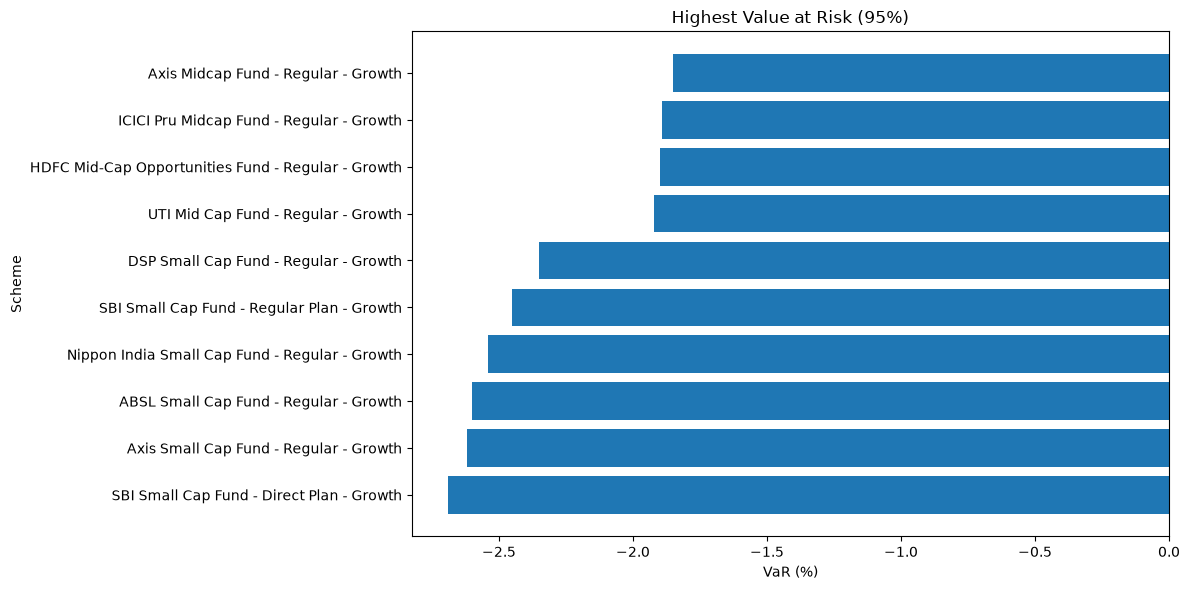

In [24]:
plt.figure(figsize=(12,6))

plt.barh(
    highest_var["scheme_name"],
    highest_var["VaR 95 (%)"]
)

plt.title("Highest Value at Risk (95%)")

plt.xlabel("VaR (%)")

plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

## Insight

Value at Risk (VaR) estimates the potential one-day loss at a 95% confidence level based on historical returns. Funds with larger negative VaR values may experience greater short-term downside risk during adverse market conditions.

In [25]:
summary = performance[
    [
        "scheme_name",
        "CAGR (%)",
        "Volatility (%)",
        "Sharpe Calculated",
        "Maximum Drawdown (%)",
        "VaR 95 (%)"
    ]
]

summary.head(10)

,scheme_name,CAGR (%),Volatility (%),Sharpe Calculated,Maximum Drawdown (%),VaR 95 (%)
0,SBI Bluechip Fund - Regular Plan - Growth,25.80,13.741434,1.440898,-15.01,-1.28
1,SBI Bluechip Fund - Direct Plan - Growth,21.52,13.939368,1.113393,-11.80,-1.35
2,SBI Small Cap Fund - Regular Plan - Growth,32.42,25.140579,1.050891,-28.71,-2.45
3,SBI Small Cap Fund - Direct Plan - Growth,2.05,24.950125,-0.158316,-52.57,-2.69
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.89,3.967062,-0.027728,-4.33,-0.39
5,HDFC Top 100 Fund - Regular Plan - Growth,2.64,14.548135,-0.230957,-24.73,-1.44
6,HDFC Top 100 Fund - Direct Plan - Growth,19.02,14.668867,0.887594,-15.20,-1.46
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12,18.936711,1.273716,-16.22,-1.90
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,11.30,18.352430,0.288790,-21.12,-1.84
9,HDFC Short Term Debt Fund - Regular - Growth,4.46,3.905246,-0.394341,-4.31,-0.38


In [26]:
best_funds = (
    summary
    .sort_values(
        "Sharpe Calculated",
        ascending=False
    )
    .head(10)
)

best_funds

,scheme_name,CAGR (%),Volatility (%),Sharpe Calculated,Maximum Drawdown (%),VaR 95 (%)
14,ICICI Pru Liquid Fund - Regular - Growth,7.24,0.493913,2.510566,-0.10,-0.02
23,Kotak Liquid Fund - Regular - Growth,6.92,0.513317,1.792265,-0.12,-0.03
34,Mirae Asset Large Cap Fund - Regular - Growth,30.97,14.193707,1.759230,-11.27,-1.36
22,Kotak Flexicap Fund - Regular - Growth,30.91,15.886987,1.567950,-12.97,-1.45
36,Mirae Asset Tax Saver Fund - Regular - Growth,31.95,17.674007,1.468258,-16.40,-1.71
0,SBI Bluechip Fund - Regular Plan - Growth,25.80,13.741434,1.440898,-15.01,-1.28
12,ICICI Pru Midcap Fund - Regular - Growth,32.83,19.290949,1.390808,-18.19,-1.89
38,DSP Midcap Fund - Regular - Growth,29.58,17.746159,1.328738,-17.25,-1.79
15,Nippon India Large Cap Fund - Regular - Growth,24.05,14.148352,1.275767,-17.41,-1.40
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,30.12,18.936711,1.273716,-16.22,-1.90


# Conclusion

This notebook evaluated mutual fund performance using multiple financial metrics.

### Key Metrics Analysed

- CAGR
- Annualized Volatility
- Sharpe Ratio
- Maximum Drawdown
- Value at Risk (VaR)

### Key Observations

- Some small-cap funds generated the highest long-term returns but also exhibited higher volatility.
- Funds with higher Sharpe Ratios delivered better returns relative to the risk taken.
- Maximum Drawdown highlighted the potential downside during market corrections.
- VaR provided an estimate of short-term downside risk.

These metrics together offer a comprehensive assessment of mutual fund performance and help investors balance return expectations with risk tolerance.